In [1]:
from rdkit import Chem
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

num_bits_per_fingerprint = 2048
fingerprint_radii = 8
feature_labels = [f'fp_{i}' for i in range(num_bits_per_fingerprint)]

In [2]:
def featurize_molecule(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return np.array(GetMorganFingerprintAsBitVect(mol, fingerprint_radii, num_bits_per_fingerprint)).tolist()
    else:
        print(f"invalid smiles: {smiles}")
        quit()

In [3]:
df = pd.read_csv('binding_affinities.csv')
df['features'] = df['Ligand SMILES'].apply(featurize_molecule)
df = df.dropna(subset=['features'])

# Split features into separate columns
features_df = pd.DataFrame(df['features'].tolist(), columns=feature_labels)
df = pd.concat([df, features_df], axis=1)
df = df.drop(columns=['features'])

# Get X and Y
X = df[feature_labels]
y = df['IC50 (nM)']

# Split data into training set and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': randint(50, 301),
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5)
}
model = RandomForestRegressor(random_state=42, n_estimators=235, max_features='sqrt', min_samples_leaf=2)
model.fit(X_train, y_train)
#random_search = RandomizedSearchCV(estimator=rfmodel, param_distributions=param_dist, n_iter=50, cv=5, n_jobs=-1, verbose=2, random_state=42)
#random_search.fit(X_train, y_train)

#model = random_search.best_estimator_
#print(random_search.best_estimator_.get_params)

RandomForestRegressor(max_features='sqrt', min_samples_leaf=2, n_estimators=235,
                      random_state=42)

In [5]:
from sklearn.metrics import r2_score


y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'Test R^2 score: {r2}')

train_pred = model.predict(X_train)
r2_train = r2_score(y_train, train_pred)
print(f"Train R^2 {r2_train}")

for dp in zip(y_test, y_pred):
    print(f"{dp[0]} : {dp[1]}")

Test R^2 score: 0.467497600368597
Train R^2 0.7385804677494981
0.9 : 19.493413333588745
69.0 : 37.03790163310043
0.56 : 0.7399893204227446
0.88 : 0.9407111827661108
0.24 : 1.5716580977925145
1.8 : 5.489993038221884
24.0 : 18.287754783754696
0.4 : 2.612942625797222
6.6 : 32.51172018188514
1.3 : 2.9332997136573864
4.0 : 8.485095283422604
4.9 : 11.764364268764501
39.0 : 8.272006060106653
6.1 : 19.399030620244844
83.0 : 27.151285191336584
0.14 : 0.5194987264420828
40.0 : 17.1887935083435
20.0 : 22.289039766536483
12.0 : 7.699272909870229
4.6 : 11.83794276795306
3.3 : 22.109982815335144
2.0 : 25.724155809298495
18.0 : 21.712645974640633
2.9 : 15.149931730184232
0.250035 : 1.6591239845474244
50.0 : 26.049912940593423
6.1 : 2.1751820189057933
40.0 : 36.77927844778641
27.0 : 22.894728068247996
1.5 : 12.056897147047648
12.0 : 11.815843182518732
2.0 : 14.135392979124894
9.8 : 25.116524233960856
0.3 : 2.215156060595527
1.1 : 18.098351612339133
69.0 : 23.950939201693114
2.6 : 4.315284147959214
0.6

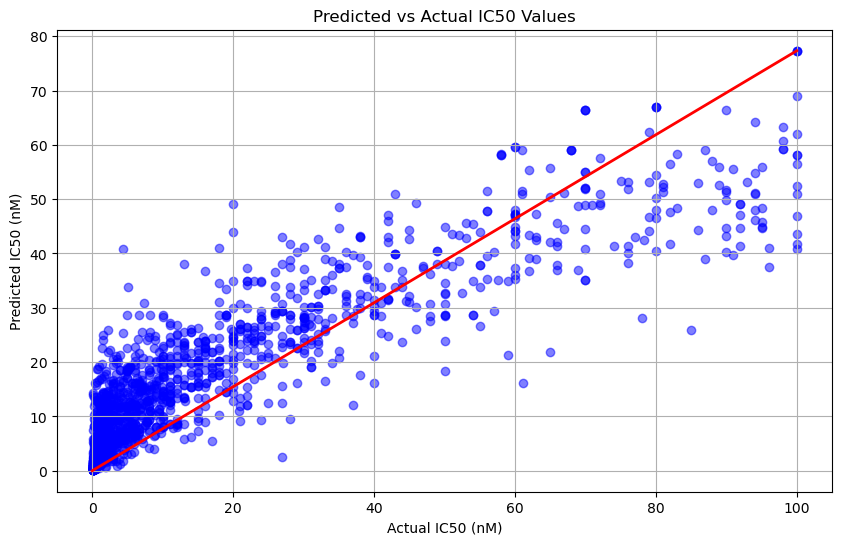

In [6]:
import math
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_train, train_pred, color='blue', alpha=0.5)
plt.plot([0, max(y_train)], [0, max(train_pred)], color='red', lw=2)
plt.xlabel('Actual IC50 (nM)')
plt.ylabel('Predicted IC50 (nM)')
plt.title('Predicted vs Actual IC50 Values')
plt.grid(True)
plt.show()

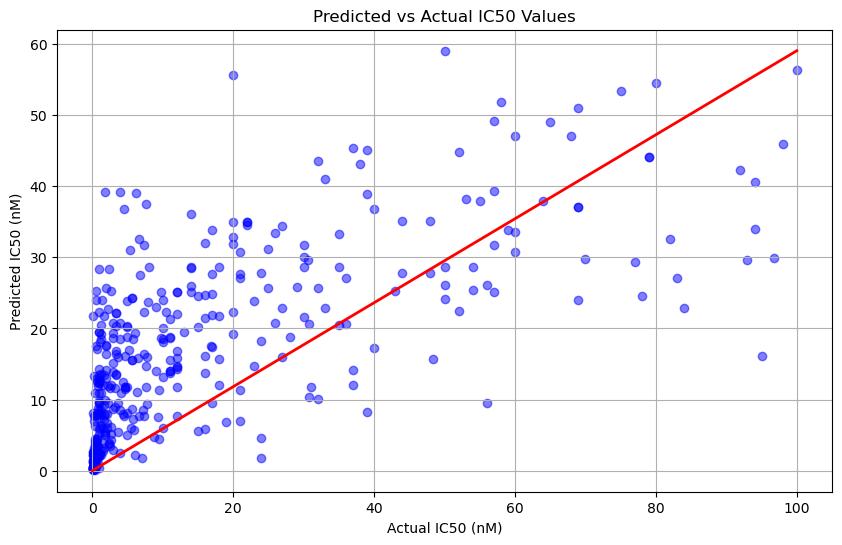

In [7]:
import math
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([0, max(y_test)], [0, max(y_pred)], color='red', lw=2)
plt.xlabel('Actual IC50 (nM)')
plt.ylabel('Predicted IC50 (nM)')
plt.title('Predicted vs Actual IC50 Values')
plt.grid(True)
plt.show()

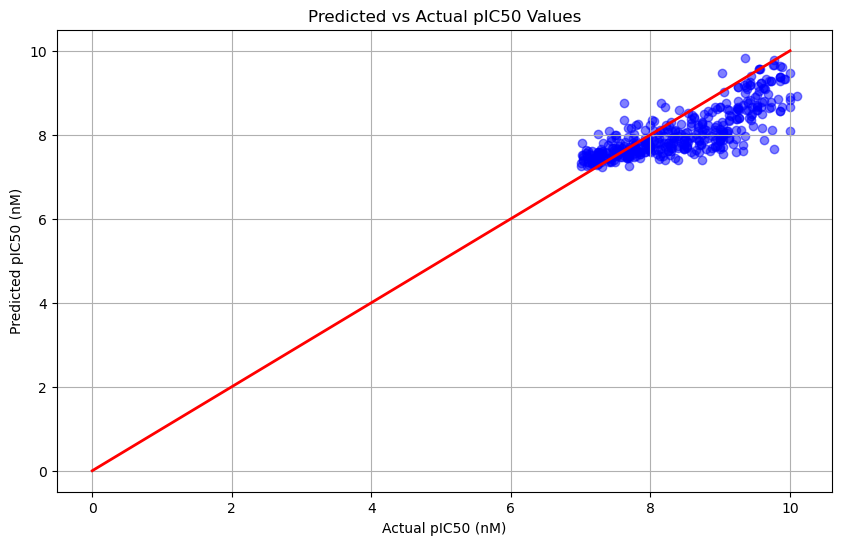

In [8]:
y_test_p = y_test.apply(lambda ic : -math.log10(ic) + 9)
y_pred_p = [-1 * math.log10(ic) + 9 for ic in y_pred]

plt.figure(figsize=(10, 6))
plt.scatter(y_test_p, y_pred_p, color='blue', alpha=0.5)
plt.plot([0, 10], [0, 10], color='red', lw=2)
plt.xlabel('Actual pIC50 (nM)')
plt.ylabel('Predicted pIC50 (nM)')
plt.title('Predicted vs Actual pIC50 Values')
plt.grid(True)
plt.show()